In [8]:
import os
import json
import requests
import zipfile
from pycocotools.coco import COCO
from tqdm import tqdm
import shutil
import random

In [ ]:
TARGET_CLASSES = ["person", "car", "dog", "cat", "chair", "bottle", "laptop", "cup", "bus", "truck"]
MAX_IMAGES = 1000
DATA_DIR = "./data/coco_subset"
IMG_DIR = os.path.join(DATA_DIR, "train")
ANN_FILE_NAME = "annotations.json"
URL_ANNOTATIONS = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ZIP_FILE = "annotations_trainval2017.zip"
ANN_FILE_PATH = "annotations/instances_val2017.json"

## Скачивание датасета

In [ ]:
def download_file(url, filename):
    """Скачивает файл с прогресс-баром"""
    if os.path.exists(filename):
        print(f"{filename} уже существует.")
        return
    print(f"Скачивание {filename}...")
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)
    with open(filename, 'wb') as file:
        for data in response.iter_content(block_size):
            progress_bar.update(len(data))
            file.write(data)
    progress_bar.close()

def main():
    if os.path.exists(DATA_DIR):
        print("Папка с данными уже есть")
    else:
        os.makedirs(IMG_DIR, exist_ok=True)

    if not os.path.exists(ZIP_FILE):
        download_file(URL_ANNOTATIONS, ZIP_FILE)
    
    if not os.path.exists("annotations"):
        print("Распаковка аннотаций...")
        with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
            zip_ref.extractall(".")

    if not os.path.exists(ANN_FILE_PATH):
        print(f"ОШИБКА: Файл {ANN_FILE_PATH} не найден")
        return

    coco = COCO(ANN_FILE_PATH)

    cat_ids = coco.getCatIds(catNms=TARGET_CLASSES)
    print(f"ID выбранных классов: {cat_ids}")

    img_ids = set()
    for cat_id in cat_ids:
        ids = coco.getImgIds(catIds=[cat_id])
        img_ids.update(ids)
    
    img_ids = list(img_ids)
    random.shuffle(img_ids)
    
    img_ids = img_ids[:MAX_IMAGES]
    print(f"Выбрано {len(img_ids)} изображений для скачивания.")
    imgs_info = coco.loadImgs(img_ids)
    
    valid_images = []
    
    for img in tqdm(imgs_info):
        img_url = img['coco_url']
        file_name = img['file_name']
        save_path = os.path.join(IMG_DIR, file_name)
        
        if os.path.exists(save_path):
            valid_images.append(img)
            continue
            
        try:
            img_data = requests.get(img_url, timeout=10).content
            with open(save_path, 'wb') as handler:
                handler.write(img_data)
            valid_images.append(img)
        except Exception as e:
            pass

    valid_img_ids = [img['id'] for img in valid_images]
    
    ann_ids = coco.getAnnIds(imgIds=valid_img_ids, catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)
    
    dataset_subset = {
        "images": valid_images,
        "annotations": anns,
        "categories": coco.loadCats(cat_ids)
    }
    
    output_file = os.path.join(DATA_DIR, ANN_FILE_NAME)
    with open(output_file, 'w') as f:
        json.dump(dataset_subset, f)
        
    print(f"Готово! Датасет сохранен в: {output_file}")
    print(f"Всего изображений: {len(valid_images)}")
    print(f"Всего аннотаций: {len(anns)}")

In [11]:
main()

Скачивание annotations_trainval2017.zip...


100%|██████████| 253M/253M [00:12<00:00, 20.5MiB/s] 


Распаковка аннотаций...
Инициализация COCO API...
loading annotations into memory...
Done (t=0.58s)
creating index...
index created!
ID выбранных классов: [1, 3, 6, 8, 17, 18, 44, 47, 62, 73]
Выбрано 1000 изображений для скачивания.
Скачивание изображений...


100%|██████████| 1000/1000 [13:00<00:00,  1.28it/s]


Создание итогового JSON...
Готово! Датасет сохранен в: ./data/coco_subset/annotations.json
Всего изображений: 1000
Всего аннотаций: 5031


In [12]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
from pycocotools.coco import COCO

## Подготовка датасета

In [ ]:
class CocoDetrDataset(Dataset):
    def __init__(self, root, ann_file, processor, train=True):
        self.root = root
        self.coco = COCO(ann_file)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.processor = processor
        
        cats = self.coco.loadCats(self.coco.getCatIds())
        self.cat_id_to_label = {cat['id']: i for i, cat in enumerate(cats)}
        self.label_to_cat_name = {i: cat['name'] for i, cat in enumerate(cats)}

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info['file_name']
        
        img_path = os.path.join(self.root, path)
        img = Image.open(img_path).convert("RGB")
        
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        
        formatted_anns = []
        for ann in anns:
            new_ann = ann.copy()
            if ann['category_id'] in self.cat_id_to_label:
                new_ann['category_id'] = self.cat_id_to_label[ann['category_id']]
                formatted_anns.append(new_ann)
        
        target_coco_format = {
            'image_id': img_id,
            'annotations': formatted_anns
        }

        encoding = self.processor(
            images=img, 
            annotations=target_coco_format, 
            return_tensors="pt"
        )
        
        pixel_values = encoding["pixel_values"].squeeze() 
        target = encoding["labels"][0] 
        
        target['image_id'] = torch.tensor([img_id])
        target['orig_size'] = torch.tensor([img.height, img.width]) 
        target['size'] = torch.tensor([int(pixel_values.shape[1]), int(pixel_values.shape[2])])

        return pixel_values, target

    def __len__(self):
        return len(self.ids)

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    return pixel_values, labels

In [27]:
import os
import torch
from torch.utils.data import DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import profile, record_function, ProfilerActivity

## Обучение без аугментации

In [54]:
DATA_DIR = "./data/coco_subset/train"
ANN_FILE = "./data/coco_subset/annotations.json"
OUTPUT_DIR = "./output_detr"
EPOCHS = 5
BATCH_SIZE = 16
LR = 5e-5

In [55]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
    
dataset = CocoDetrDataset(DATA_DIR, ANN_FILE, processor)
print(f"Dataset size: {len(dataset)}")

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Dataset size: 1000


In [ ]:
def padded_collate(batch):
    pixel_values, labels = collate_fn(batch)
    batch_encoding = processor.pad(pixel_values, return_tensors="pt")
    
    return batch_encoding, labels


In [ ]:
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=padded_collate)

id2label = dataset.label_to_cat_name
num_classes = len(id2label)

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    revision="no_timm"
)
model.to(device)

Some weights of DetrForObjectDetection were not initialized from the model checkpoint at facebook/detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.weight: found shape torch.Size([92, 256]) in the checkpoint and torch.Size([11, 256]) in the model instantiated
- class_labels_classifier.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): ResNetBackbone(
          (embedder): ResNetEmbeddings(
            (embedder): ResNetConvLayer(
              (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
              (normalization): DetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          )
          (encoder): ResNetEncoder(
            (stages): ModuleList(
              (0): ResNetStage(
                (layers): Sequential(
                  (0): ResNetBottleNeckLayer(
                    (shortcut): ResNetShortCut(
                      (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                      (normalization): DetrFrozenBatchNorm2d()
                    )
                    (layer): Seq

In [59]:
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": LR * 0.1,
    },
]

In [ ]:
optimizer = torch.optim.AdamW(param_dicts, lr=LR, weight_decay=1e-4)

writer = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, "logs"))

In [61]:
prof = torch.profiler.profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        schedule=torch.profiler.schedule(wait=2, warmup=2, active=3, repeat=1),
        on_trace_ready=torch.profiler.tensorboard_trace_handler(os.path.join(OUTPUT_DIR, "profiler")),
        record_shapes=True,
        with_stack=True
)
prof.start()

model.train()
global_step = 0

In [ ]:
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, (encoding, labels) in enumerate(train_loader):
        
        pixel_values = encoding["pixel_values"].to(device)
        pixel_mask = encoding["pixel_mask"].to(device)
        
        labels = [{k: v.to(device) for k, v in t.items()} for t in labels]

        optimizer.zero_grad()
        
        with record_function("model_forward"):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        prof.step() 

        current_loss = loss.item()
        epoch_loss += current_loss
        global_step += 1
        
        if step % 10 == 0:
            writer.add_scalar("Loss/total", current_loss, global_step)
            writer.add_scalar("Loss/bbox", outputs.loss_dict['loss_bbox'].item(), global_step)
            writer.add_scalar("Loss/class", outputs.loss_dict['loss_ce'].item(), global_step)
            print(f"Epoch {epoch} | Step {step} | Loss {current_loss:.4f}")

    print(f"Epoch {epoch} finished. Avg Loss: {epoch_loss/len(train_loader):.4f}")
    model.save_pretrained(os.path.join(OUTPUT_DIR, f"checkpoint-{epoch}"))

prof.stop()
writer.close()
print("Training complete.")

Epoch 0 | Step 0 | Loss 3.0398
Epoch 0 | Step 10 | Loss 2.8946
Epoch 0 | Step 20 | Loss 2.8118
Epoch 0 | Step 30 | Loss 2.3660
Epoch 0 | Step 40 | Loss 2.3643
Epoch 0 | Step 50 | Loss 1.9273
Epoch 0 | Step 60 | Loss 1.6829
Epoch 0 finished. Avg Loss: 2.3918
Epoch 1 | Step 0 | Loss 1.9483
Epoch 1 | Step 10 | Loss 2.2353
Epoch 1 | Step 20 | Loss 1.8378
Epoch 1 | Step 30 | Loss 1.9868
Epoch 1 | Step 40 | Loss 1.7094
Epoch 1 | Step 50 | Loss 1.7599
Epoch 1 | Step 60 | Loss 1.5752
Epoch 1 finished. Avg Loss: 1.7886
Epoch 2 | Step 0 | Loss 1.1867
Epoch 2 | Step 10 | Loss 1.8104
Epoch 2 | Step 20 | Loss 1.8161
Epoch 2 | Step 30 | Loss 1.7460
Epoch 2 | Step 40 | Loss 1.6950
Epoch 2 | Step 50 | Loss 1.3029
Epoch 2 | Step 60 | Loss 1.5829
Epoch 2 finished. Avg Loss: 1.6603
Epoch 3 | Step 0 | Loss 2.0463
Epoch 3 | Step 10 | Loss 1.7336
Epoch 3 | Step 20 | Loss 1.9047
Epoch 3 | Step 30 | Loss 1.4937
Epoch 3 | Step 40 | Loss 1.3773
Epoch 3 | Step 50 | Loss 1.2375
Epoch 3 | Step 60 | Loss 1.4392
Epo

## Вывод графиков

Чтение логов из файла: ./output_detr/logs/events.out.tfevents.1766597227.x32-01.2610303.3
Найденные метрики: ['Loss/total', 'Loss/bbox', 'Loss/class']


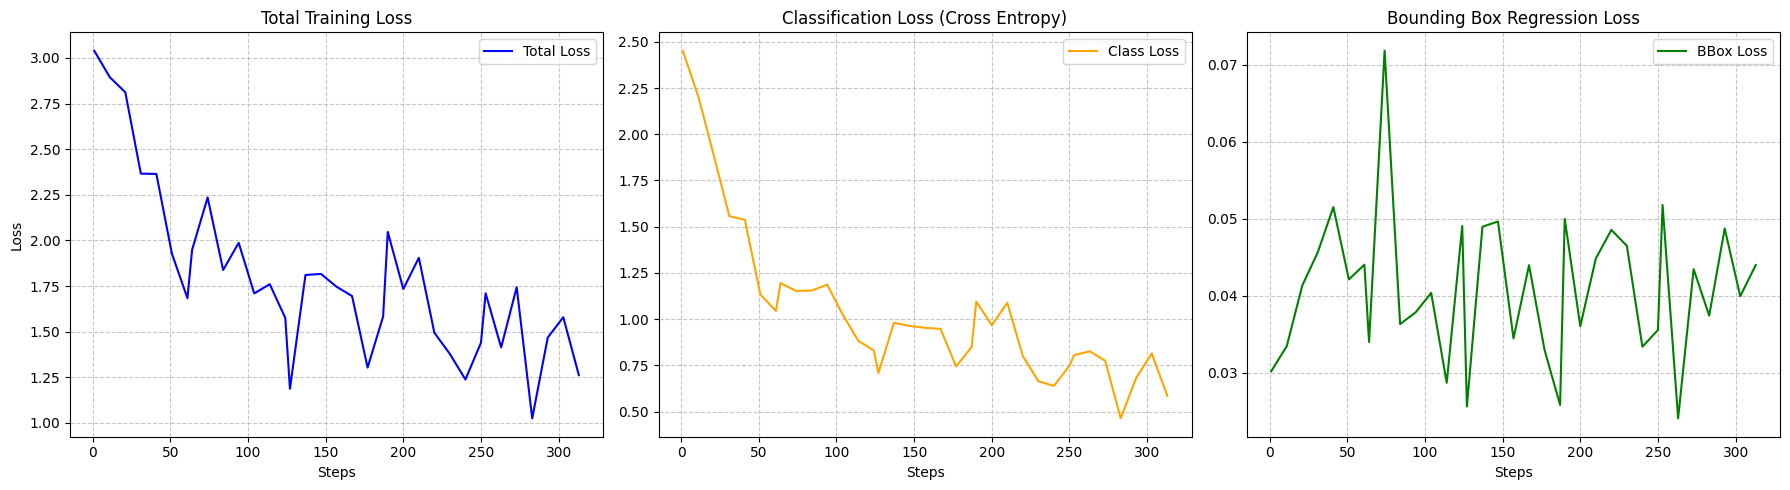

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


LOG_DIR = "./output_detr/logs"

def plot_training_metrics(log_dir):
    # 1. Ищем файл логов (он имеет сложное имя events.out.tfevents...)
    # Берем самый свежий файл, если их несколько
    list_of_files = glob.glob(os.path.join(log_dir, "events.out.tfevents*"))
    
    if not list_of_files:
        print(f"Ошибка: В папке {log_dir} нет файлов логов!")
        return

    latest_file = max(list_of_files, key=os.path.getctime)
    print(f"Чтение логов из файла: {latest_file}")

    # 2. Загружаем данные через EventAccumulator
    event_acc = EventAccumulator(latest_file)
    event_acc.Reload()

    # Смотрим, какие теги (имена метрик) есть в файле
    tags = event_acc.Tags()['scalars']
    print("Найденные метрики:", tags)

    # 3. Извлекаем данные для графиков
    # Названия тегов должны совпадать с тем, что мы писали в writer.add_scalar в train.py
    metrics_to_plot = [
        'Loss/total', 
        'Loss/bbox', 
        'Loss/class'
    ]
    
    data = {}
    for tag in metrics_to_plot:
        if tag in tags:
            events = event_acc.Scalars(tag)
            steps = [e.step for e in events]
            values = [e.value for e in events]
            data[tag] = (steps, values)
        else:
            print(f"Внимание: Метрика {tag} не найдена в логах.")

    # 4. Рисуем графики matplotlib
    if not data:
        return

    plt.figure(figsize=(18, 5))

    # График 1: Общий Loss
    if 'Loss/total' in data:
        steps, values = data['Loss/total']
        plt.subplot(1, 3, 1)
        plt.plot(steps, values, label='Total Loss', color='blue')
        plt.title("Total Training Loss")
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

    # График 2: Ошибка классификации (Class Loss)
    if 'Loss/class' in data:
        steps, values = data['Loss/class']
        plt.subplot(1, 3, 2)
        plt.plot(steps, values, label='Class Loss', color='orange')
        plt.title("Classification Loss (Cross Entropy)")
        plt.xlabel("Steps")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

    # График 3: Ошибка рамок (BBox Loss)
    if 'Loss/bbox' in data:
        steps, values = data['Loss/bbox']
        plt.subplot(1, 3, 3)
        plt.plot(steps, values, label='BBox Loss', color='green')
        plt.title("Bounding Box Regression Loss")
        plt.xlabel("Steps")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_metrics(LOG_DIR)

# 2.5

In [64]:
import os
import json
import cv2
import numpy as np
import torch
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

In [ ]:
SOURCE_JSON = "./data/coco_subset/annotations.json"
IMG_DIR = "./data/coco_subset/train"
TARGET_CLASS = "cat"
NUM_NEW_IMAGES = 100   
OUTPUT_DIR = "./data/coco_subset/synthetic_train"

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)


print("Loading Diffusion models...")
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")
pipe.enable_attention_slicing()

with open(SOURCE_JSON, 'r') as f:
    coco_data = json.load(f)

cat_id = next(c['id'] for c in coco_data['categories'] if c['name'] == TARGET_CLASS)

Loading Diffusion models...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.48it/s]


In [ ]:

img_ids_with_cat = set()
for ann in coco_data['annotations']:
    if ann['category_id'] == cat_id:
        img_ids_with_cat.add(ann['image_id'])
        
images_to_process = [img for img in coco_data['images'] if img['id'] in img_ids_with_cat]
print(f"Found {len(images_to_process)} images with {TARGET_CLASS}")

new_images = []
new_annotations = []

max_img_id = max(img['id'] for img in coco_data['images'])
max_ann_id = max(ann['id'] for ann in coco_data['annotations'])

count = 0
for img_info in images_to_process:
    if count >= NUM_NEW_IMAGES: break
    
    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    orig_image = Image.open(img_path).convert("RGB")
    

    image_np = np.array(orig_image)
    orig_w, orig_h = orig_image.size
    target_size = (512, 512)
    
    resized_image = cv2.resize(image_np, target_size)
    canny_image = cv2.Canny(resized_image, 100, 200)
    canny_image = canny_image[:, :, None]
    canny_image = np.concatenate([canny_image, canny_image, canny_image], axis=2)
    canny_pil = Image.fromarray(canny_image)
    
    prompt = f"A high quality photo of a {TARGET_CLASS}, cinematic lighting, photorealistic"
    out_image = pipe(prompt, image=canny_pil, num_inference_steps=20).images[0]
    
    new_filename = f"syn_{count}_{img_info['file_name']}"
    save_path = os.path.join(OUTPUT_DIR, new_filename)
    out_image.save(save_path)
    
    new_img_id = max_img_id + count + 1
    new_images.append({
        "id": new_img_id,
        "file_name": os.path.join("..", "synthetic_train", new_filename), 
        "width": 512,
        "height": 512
    })
    
    scale_x = 512 / orig_w
    scale_y = 512 / orig_h
    
    related_anns = [a for a in coco_data['annotations'] if a['image_id'] == img_info['id']]
    for ann in related_anns:
        new_ann = ann.copy()
        new_ann['id'] = max_ann_id + len(new_annotations) + 1
        new_ann['image_id'] = new_img_id
        
        x, y, w, h = ann['bbox']
        new_ann['bbox'] = [x * scale_x, y * scale_y, w * scale_x, h * scale_y]
        new_ann['area'] = ann['area'] * scale_x * scale_y
        
        new_annotations.append(new_ann)
        
    count += 1
    print(f"Generated {new_filename}")

coco_data['images'].extend(new_images)
coco_data['annotations'].extend(new_annotations)

with open(SOURCE_JSON.replace(".json", "_augmented.json"), 'w') as f:
    json.dump(coco_data, f)
    
print("Augmented dataset JSON saved!")

Found 40 images with cat


100%|██████████| 20/20 [00:01<00:00, 12.60it/s]


Generated syn_0_000000058111.jpg


100%|██████████| 20/20 [00:01<00:00, 12.68it/s]


Generated syn_1_000000364297.jpg


...

Generated syn_37_000000134096.jpg


100%|██████████| 20/20 [00:01<00:00, 12.83it/s]


Generated syn_38_000000311789.jpg


100%|██████████| 20/20 [00:01<00:00, 12.55it/s]


Generated syn_39_000000403817.jpg
Augmented dataset JSON saved!


In [86]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image
import glob
import random

In [ ]:
CHECKPOINT = "./output_detr/checkpoint-4" 
TEST_IMG_DIR = "./data/coco_subset/train"
CLASSES = ["person", "car", "dog", "cat", "chair", "bottle", "laptop", "cup", "bus", "truck"]

Loading model from ./output_detr/checkpoint-4...



Image: ./data/coco_subset/train/000000078426.jpg


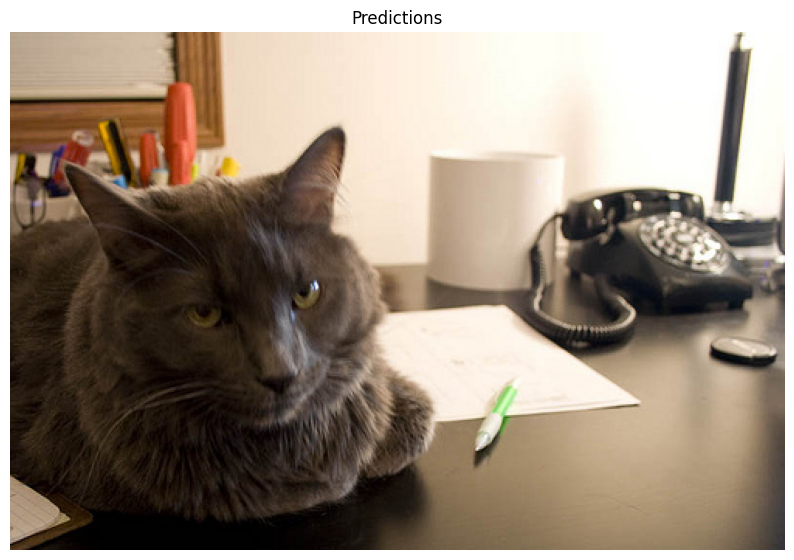


Image: ./data/coco_subset/train/000000304404.jpg
Detected person with confidence 0.58 at [19, 53, 48, 83]
Detected person with confidence 0.64 at [284, 60, 313, 87]
Detected person with confidence 0.64 at [291, 27, 316, 68]
Detected person with confidence 0.74 at [259, 25, 283, 85]
Detected person with confidence 0.55 at [113, 24, 135, 67]
Detected person with confidence 0.61 at [75, 180, 124, 243]
Detected person with confidence 0.72 at [558, 125, 606, 232]
Detected person with confidence 0.60 at [31, 21, 63, 72]
Detected person with confidence 0.56 at [58, 24, 85, 63]
Detected person with confidence 0.67 at [490, 158, 524, 231]
Detected person with confidence 0.70 at [481, 159, 521, 232]
Detected person with confidence 0.62 at [254, 25, 278, 76]
Detected person with confidence 0.53 at [0, 49, 22, 82]
Detected person with confidence 0.53 at [0, 168, 83, 324]
Detected person with confidence 0.59 at [241, 59, 264, 89]
Detected person with confidence 0.67 at [531, 159, 577, 235]
Detecte

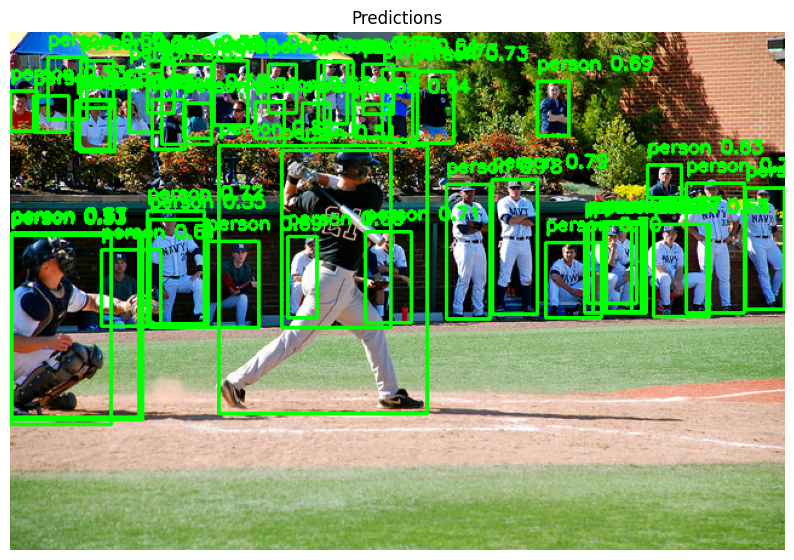


Image: ./data/coco_subset/train/000000414385.jpg
Detected person with confidence 0.73 at [402, 250, 466, 378]


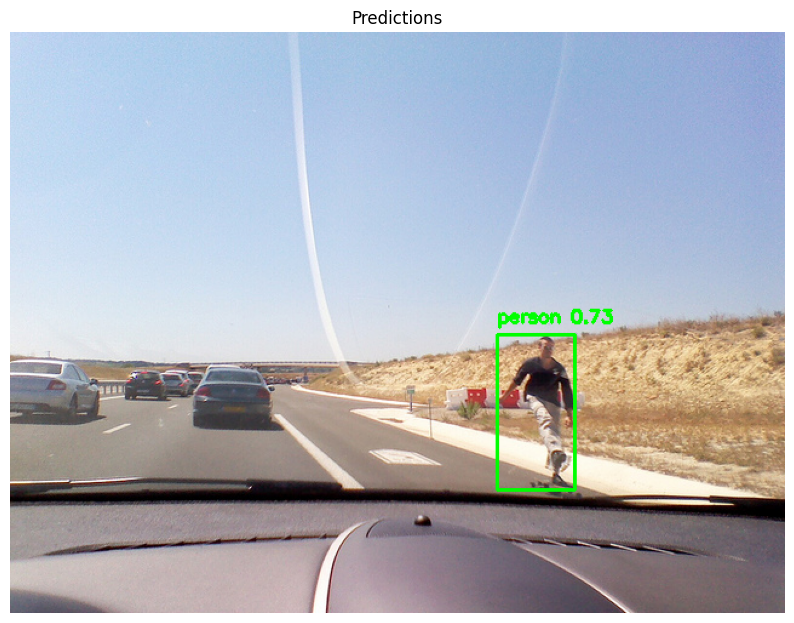

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
print(f"Loading model from {CHECKPOINT}...")
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
model = DetrForObjectDetection.from_pretrained(CHECKPOINT)
model.to(device)
model.eval()

image_paths = glob.glob(f"{TEST_IMG_DIR}/*.jpg")
sample_images = random.sample(image_paths, 3)

for img_path in sample_images:
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)


    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

    img_np = np.array(image)
    img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    
    print(f"\nImage: {img_path}")
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [int(i) for i in box.tolist()]

        if label < len(CLASSES):
            label_text = CLASSES[label.item()]
        else:
            label_text = str(label.item())
            
        print(f"Detected {label_text} with confidence {score.item():.2f} at {box}")
        
        cv2.rectangle(img_cv, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(img_cv, f"{label_text} {score:.2f}", (box[0], box[1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Predictions")
    plt.show()

In [ ]:
DATA_DIR = "./data/coco_subset/train" 

ANN_FILE = "./data/coco_subset/annotations_augmented.json"

OUTPUT_DIR = "./output_synthetic"

## Обучение с аугментациями

In [ ]:

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Training on Augmented Dataset: {ANN_FILE}")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")

if not os.path.exists(ANN_FILE):
    raise FileNotFoundError(f"Файл {ANN_FILE} не найден. Сначала запустите gen_synthetic.py!")
    
dataset = CocoDetrDataset(DATA_DIR, ANN_FILE, processor)
print(f"Augmented Dataset size: {len(dataset)} images")

def padded_collate(batch):
    pixel_values, labels = collate_fn(batch)
    batch_encoding = processor.pad(pixel_values, return_tensors="pt")
    return batch_encoding, labels

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=padded_collate)

num_classes = len(dataset.cat_id_to_label)

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    revision="no_timm"
)
model.to(device)

param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": LR * 0.1,
    },
]
optimizer = torch.optim.AdamW(param_dicts, lr=LR, weight_decay=1e-4)

writer = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, "logs"))

print("Starting augmented training...")
model.train()
global_step = 0

for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, (encoding, labels) in enumerate(train_loader):
        pixel_values = encoding["pixel_values"].to(device)
        pixel_mask = encoding["pixel_mask"].to(device)
        
        labels_on_device = []
        for t in labels:
            t_dev = {k: v.to(device) for k, v in t.items()}
            labels_on_device.append(t_dev)

        optimizer.zero_grad()
        
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels_on_device)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        epoch_loss += current_loss
        global_step += 1
        
        if step % 10 == 0:
            writer.add_scalar("Loss/total", current_loss, global_step)
            writer.add_scalar("Loss/bbox", outputs.loss_dict['loss_bbox'].item(), global_step)
            writer.add_scalar("Loss/class", outputs.loss_dict['loss_ce'].item(), global_step)
            print(f"Epoch {epoch} | Step {step} | Loss {current_loss:.4f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch} finished. Avg Loss: {avg_loss:.4f}")
    
    model.save_pretrained(os.path.join(OUTPUT_DIR, f"checkpoint-{epoch}"))

writer.close()
print(f"Augmented training finished! Model saved to {OUTPUT_DIR}")

Using device: cuda
Training on Augmented Dataset: ./data/coco_subset/annotations_augmented.json
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Augmented Dataset size: 1040 images


Some weights of DetrForObjectDetection were not initialized from the model checkpoint at facebook/detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.weight: found shape torch.Size([92, 256]) in the checkpoint and torch.Size([11, 256]) in the model instantiated
- class_labels_classifier.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting augmented training...
Epoch 0 | Step 0 | Loss 3.1086
Epoch 0 | Step 10 | Loss 2.6741
Epoch 0 | Step 20 | Loss 2.6849
Epoch 0 | Step 30 | Loss 2.5726
Epoch 0 | Step 40 | Loss 2.3419
Epoch 0 | Step 50 | Loss 2.1511
Epoch 0 | Step 60 | Loss 2.0478
Epoch 0 finished. Avg Loss: 2.3307
Epoch 1 | Step 0 | Loss 1.9045
Epoch 1 | Step 10 | Loss 1.9265
Epoch 1 | Step 20 | Loss 1.5458
Epoch 1 | Step 30 | Loss 1.5840
Epoch 1 | Step 40 | Loss 1.8920
Epoch 1 | Step 50 | Loss 2.1360
Epoch 1 | Step 60 | Loss 1.4910
Epoch 1 finished. Avg Loss: 1.7726
Epoch 2 | Step 0 | Loss 1.6291
Epoch 2 | Step 10 | Loss 1.8846
Epoch 2 | Step 20 | Loss 1.7177
Epoch 2 | Step 30 | Loss 1.4154
Epoch 2 | Step 40 | Loss 1.8499
Epoch 2 | Step 50 | Loss 1.7519
Epoch 2 | Step 60 | Loss 1.3904
Epoch 2 finished. Avg Loss: 1.6271
Epoch 3 | Step 0 | Loss 1.5773
Epoch 3 | Step 10 | Loss 1.3628
Epoch 3 | Step 20 | Loss 1.5850
Epoch 3 | Step 30 | Loss 1.3949
Epoch 3 | Step 40 | Loss 1.8900
Epoch 3 | Step 50 | Loss 1.7198
Epoc

## Сравнение

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm 

VAL_IMG_DIR = "./data/coco_subset/train" 
VAL_ANN_FILE = "./data/coco_subset/annotations.json"

BASELINE_MODEL_PATH = "./output_detr/checkpoint-4" 
AUGMENTED_MODEL_PATH = "./output_synthetic/checkpoint-4"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model_path, dataloader):
    print(f"Loading model from {model_path}...")
    try:
        model = DetrForObjectDetection.from_pretrained(model_path).to(DEVICE)
    except Exception as e:
        print(f"Error loading {model_path}: {e}")
        return {"map": 0.0, "map_50": 0.0}
        
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
    metric = MeanAveragePrecision()
    model.eval()

    print("Running evaluation...")
    with torch.no_grad():
        for pixel_values, targets in tqdm(dataloader):
            batch_encoding = processor.pad(pixel_values, return_tensors="pt")
            pixel_values_tensor = batch_encoding["pixel_values"].to(DEVICE)
            pixel_mask = batch_encoding["pixel_mask"].to(DEVICE)

            outputs = model(pixel_values=pixel_values_tensor, pixel_mask=pixel_mask)
            target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
            
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.0)

            preds = []
            target_formatted = []

            for i in range(len(results)):
                preds.append({
                    "boxes": results[i]["boxes"].cpu(),
                    "scores": results[i]["scores"].cpu(),
                    "labels": results[i]["labels"].cpu(),
                })
                
                boxes_norm = targets[i]["boxes"].cpu() 
                h, w = targets[i]["orig_size"] 
                
                x_c = boxes_norm[:, 0] * w
                y_c = boxes_norm[:, 1] * h
                b_w = boxes_norm[:, 2] * w
                b_h = boxes_norm[:, 3] * h
                
                boxes_abs = torch.zeros_like(boxes_norm)
                boxes_abs[:, 0] = x_c - b_w / 2
                boxes_abs[:, 1] = y_c - b_h / 2
                boxes_abs[:, 2] = x_c + b_w / 2
                boxes_abs[:, 3] = y_c + b_h / 2
                
                target_formatted.append({
                    "boxes": boxes_abs,
                    "labels": targets[i]["class_labels"].cpu()
                })

            metric.update(preds, target_formatted)

    result = metric.compute()
    return result

def main():
    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
    dataset = CocoDetrDataset(VAL_IMG_DIR, VAL_ANN_FILE, processor)
    
    dataloader = DataLoader(dataset, batch_size=4, collate_fn=collate_fn)

    print("=== Eval Baseline Model ===")
    res_base = evaluate_model(BASELINE_MODEL_PATH, dataloader)
    
    print("\n=== Eval Augmented Model ===")
    res_aug = evaluate_model(AUGMENTED_MODEL_PATH, dataloader)

    print("\n" + "="*55)
    print(f"{'Metric':<20} | {'Baseline':<12} | {'Augmented':<12}")
    print("-" * 55)
    print(f"{'mAP (IoU=0.5:0.95)':<20} | {res_base['map']:.4f}       | {res_aug['map']:.4f}")
    print(f"{'mAP (IoU=0.5)':<20} | {res_base['map_50']:.4f}       | {res_aug['map_50']:.4f}")
    print("="*55)

if __name__ == "__main__":
    main()

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
=== Eval Baseline Model ===
Loading model from ./output_detr/checkpoint-4...
Running evaluation...


100%|██████████| 250/250 [01:00<00:00,  4.12it/s]



=== Eval Augmented Model ===
Loading model from ./output_synthetic/checkpoint-4...
Running evaluation...


100%|██████████| 250/250 [01:00<00:00,  4.12it/s]



Metric               | Baseline     | Augmented   
-------------------------------------------------------
mAP (IoU=0.5:0.95)   | 0.0588       | 0.0508
mAP (IoU=0.5)        | 0.1013       | 0.0821
